# Análisis biomecánico de sentadilla mediante visión por computador

Detección de puntos anatómicos con **MediaPipe Pose Landmarker** (API moderna) y cálculo del ángulo de flexión de rodilla a lo largo del ejercicio.

**Vista:** lateral (sagital). **Variable estudiada:** ángulo de flexión de rodilla, profundidad de la sentadilla (ángulo mínimo) y duración del ciclo.

## 1. Instalar MediaPipe

In [ ]:
!pip install -q mediapipe

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 58.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 4.6 MB/s eta 0:00:00


## 2. Montar Google Drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 3. Configuración

In [ ]:
VIDEO_PATH = '/content/drive/MyDrive/sentadilla.mp4'   # <-- AJUSTAR
LADO_VISIBLE = 'derecho'        # 'derecho' o 'izquierdo'
UMBRAL_INICIO = 5.0             # grados/segundo, para detectar inicio del ejercicio
SUAVIZADO_VENTANA = 5           # frames para suavizar la señal

import os
print('Existe el vídeo:', os.path.exists(VIDEO_PATH))

Existe el vídeo: True


## 4. Descargar el modelo de MediaPipe

In [ ]:
!wget -q -O pose_landmarker.task https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_lite/float16/latest/pose_landmarker_lite.task
print('Modelo descargado')
!ls -lh pose_landmarker.task

Modelo descargado
-rw-r--r-- 1 root root 5.6M Apr 27  2023 pose_landmarker.task


## 5. Funciones auxiliares

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def calcular_angulo(a, b, c):
    """Ángulo (grados) en el vértice b, formado por los puntos a-b-c."""
    a = np.array(a)
    b = np.array(b)
    c = np.array(c)
    ba = a - b
    bc = c - b
    cos_ang = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc) + 1e-9)
    cos_ang = np.clip(cos_ang, -1.0, 1.0)
    return np.degrees(np.arccos(cos_ang))

def suavizar(senal, ventana=5):
    """Media móvil simple para reducir ruido."""
    return np.convolve(senal, np.ones(ventana) / ventana, mode='same')

## 6. Procesamiento del vídeo

MediaPipe detecta 33 puntos anatómicos por frame. Tomamos cadera, rodilla y tobillo del lado visible y calculamos el ángulo de flexión.

In [ ]:
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

# Índices de los landmarks de MediaPipe Pose
if LADO_VISIBLE == 'derecho':
    IDX_CADERA, IDX_RODILLA, IDX_TOBILLO = 24, 26, 28
else:
    IDX_CADERA, IDX_RODILLA, IDX_TOBILLO = 23, 25, 27

base_options = python.BaseOptions(model_asset_path='pose_landmarker.task')
options = vision.PoseLandmarkerOptions(
    base_options=base_options,
    running_mode=vision.RunningMode.VIDEO,
    num_poses=1,
)
detector = vision.PoseLandmarker.create_from_options(options)

cap = cv2.VideoCapture(VIDEO_PATH)
if not cap.isOpened():
    raise FileNotFoundError(f'No se pudo abrir el vídeo: {VIDEO_PATH}')

fps = cap.get(cv2.CAP_PROP_FPS)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
print(f'FPS: {fps:.2f} | Frames totales: {total_frames}')

angulos = []
tiempos = []
frame_idx = 0
frames_sin_deteccion = 0

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    img_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=img_rgb)
    timestamp_ms = int((frame_idx / fps) * 1000)

    resultado = detector.detect_for_video(mp_image, timestamp_ms)

    if resultado.pose_landmarks and len(resultado.pose_landmarks) > 0:
        lm = resultado.pose_landmarks[0]
        cadera  = [lm[IDX_CADERA].x,  lm[IDX_CADERA].y]
        rodilla = [lm[IDX_RODILLA].x, lm[IDX_RODILLA].y]
        tobillo = [lm[IDX_TOBILLO].x, lm[IDX_TOBILLO].y]
        ang = calcular_angulo(cadera, rodilla, tobillo)
        angulos.append(ang)
        tiempos.append(frame_idx / fps)
    else:
        frames_sin_deteccion += 1

    frame_idx += 1

cap.release()
detector.close()

angulos = np.array(angulos)
tiempos = np.array(tiempos)
ang_suav = suavizar(angulos, SUAVIZADO_VENTANA)

print(f'Frames con detección: {len(angulos)} de {frame_idx}')
print(f'Frames sin detección: {frames_sin_deteccion}')

FPS: 60.05 | Frames totales: 554
Frames con detección: 554 de 554
Frames sin detección: 0


## 7. Detección automática del inicio y fin del ejercicio

Usamos la velocidad angular (derivada del ángulo) para detectar cuándo empieza y termina el movimiento, evitando juicios subjetivos.

In [ ]:
velocidad = np.gradient(ang_suav, tiempos)
candidatos = np.where(np.abs(velocidad) > UMBRAL_INICIO)[0]

if len(candidatos) > 0:
    idx_inicio = candidatos[0]
    idx_fin = candidatos[-1]
else:
    idx_inicio = 0
    idx_fin = len(ang_suav) - 1

t_inicio = tiempos[idx_inicio]
t_fin = tiempos[idx_fin]
duracion = t_fin - t_inicio

ang_min = np.min(ang_suav[idx_inicio:idx_fin + 1])
flexion_max = 180 - ang_min   # 0° = pierna recta, 90° = sentadilla profunda
idx_min = np.argmin(ang_suav[idx_inicio:idx_fin + 1]) + idx_inicio
t_min = tiempos[idx_min]

## 8. Resultados

In [ ]:
print('=' * 55)
print('RESULTADOS DEL ANÁLISIS DE LA SENTADILLA')
print('=' * 55)
print(f'Lado analizado:                 {LADO_VISIBLE}')
print(f'FPS del vídeo:                  {fps:.2f}')
print(f'Frames procesados:              {len(angulos)}')
print(f'Inicio del ejercicio:           t = {t_inicio:.2f} s')
print(f'Fin del ejercicio:              t = {t_fin:.2f} s')
print(f'Duración total del ciclo:       {duracion:.2f} s')
print(f'Instante de máxima flexión:     t = {t_min:.2f} s')
print(f'Ángulo mínimo de rodilla:       {ang_min:.1f}°')
print(f'Flexión máxima de rodilla:      {flexion_max:.1f}°')
print('=' * 55)

if flexion_max < 60:
    profundidad = 'sentadilla parcial (flexión < 60°)'
elif flexion_max < 90:
    profundidad = 'sentadilla a media profundidad (60-90°)'
elif flexion_max < 120:
    profundidad = 'sentadilla profunda (>= 90°)'
else:
    profundidad = 'sentadilla muy profunda (> 120°)'
print(f'Clasificación: {profundidad}')

RESULTADOS DEL ANÁLISIS DE LA SENTADILLA
Lado analizado:                 derecho
FPS del vídeo:                  60.05
Frames procesados:              554
Inicio del ejercicio:           t = 0.00 s
Fin del ejercicio:              t = 9.21 s
Duración total del ciclo:       9.21 s
Instante de máxima flexión:     t = 2.06 s
Ángulo mínimo de rodilla:       41.6°
Flexión máxima de rodilla:      138.4°
Clasificación: sentadilla muy profunda (> 120°)


## 9. Visualización

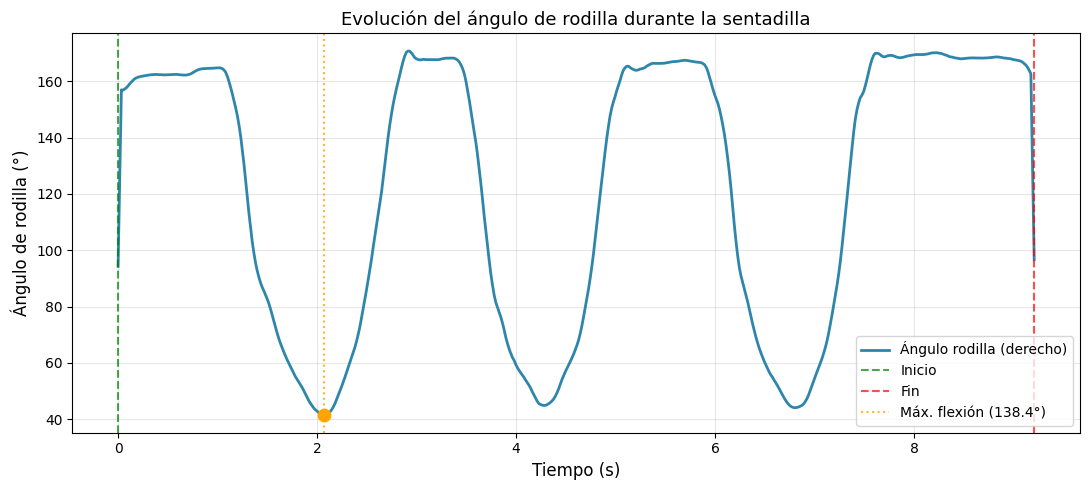

In [ ]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(tiempos, ang_suav, linewidth=2, color='#2E86AB', label=f'Ángulo rodilla ({LADO_VISIBLE})')
ax.axvline(t_inicio, color='green', linestyle='--', alpha=0.7, label='Inicio')
ax.axvline(t_fin, color='red', linestyle='--', alpha=0.7, label='Fin')
ax.axvline(t_min, color='orange', linestyle=':', alpha=0.8, label=f'Máx. flexión ({flexion_max:.1f}°)')
ax.scatter([t_min], [ang_min], color='orange', zorder=5, s=80)
ax.set_xlabel('Tiempo (s)', fontsize=12)
ax.set_ylabel('Ángulo de rodilla (°)', fontsize=12)
ax.set_title('Evolución del ángulo de rodilla durante la sentadilla', fontsize=13)
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/content/resultado_sentadilla.png', dpi=150)
plt.show()

## 10. Vídeo con esqueleto y ángulo superpuestos

In [ ]:
detector2 = vision.PoseLandmarker.create_from_options(options)

cap = cv2.VideoCapture(VIDEO_PATH)
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter('/content/sentadilla_anotada.mp4', fourcc, fps, (w, h))

# Conexiones del esqueleto (tronco, piernas, brazos)
CONEXIONES = [
    (11, 12), (11, 23), (12, 24), (23, 24),
    (23, 25), (25, 27), (27, 29), (27, 31),
    (24, 26), (26, 28), (28, 30), (28, 32),
    (11, 13), (13, 15), (12, 14), (14, 16),
]

frame_idx = 0
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break
    img_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=img_rgb)
    timestamp_ms = int((frame_idx / fps) * 1000)
    resultado = detector2.detect_for_video(mp_image, timestamp_ms)

    if resultado.pose_landmarks and len(resultado.pose_landmarks) > 0:
        lm = resultado.pose_landmarks[0]
        for i, j in CONEXIONES:
            x1, y1 = int(lm[i].x * w), int(lm[i].y * h)
            x2, y2 = int(lm[j].x * w), int(lm[j].y * h)
            cv2.line(frame, (x1, y1), (x2, y2), (255, 255, 255), 2)
        for p in lm:
            cv2.circle(frame, (int(p.x * w), int(p.y * h)), 4, (0, 0, 255), -1)
        cadera  = [lm[IDX_CADERA].x,  lm[IDX_CADERA].y]
        rodilla = [lm[IDX_RODILLA].x, lm[IDX_RODILLA].y]
        tobillo = [lm[IDX_TOBILLO].x, lm[IDX_TOBILLO].y]
        ang = calcular_angulo(cadera, rodilla, tobillo)
        px = int(rodilla[0] * w)
        py = int(rodilla[1] * h)
        cv2.putText(frame, f'{ang:.0f} grados', (px + 15, py),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 255, 0), 2)
    out.write(frame)
    frame_idx += 1

cap.release()
out.release()
detector2.close()
print('Vídeo anotado guardado en: /content/sentadilla_anotada.mp4')

Vídeo anotado guardado en: /content/sentadilla_anotada.mp4
